In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms
import numpy as np
import time
import os, shutil
import matplotlib.pyplot as plt
import tqdm
from torch.utils.tensorboard import SummaryWriter
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.finer_cam import FinerCAM
from pytorch_grad_cam.shapley_cam import ShapleyCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import optuna

c:\Source\TEAM-PJ-DEEP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:


def dataset_aplit(query, train_cnt, val_cnt)  :
    origin_file = '../data/민원문서/'+query
    directory_list = [
        '../data/dataset/train/',
        '../data/dataset/val/',
        '../data/dataset/test/',
    ]

    for dir in directory_list:
        if not os.path.isdir(dir+query): #만약 파일이 없으면
            os.makedirs(dir+query)  #만들어라

    cnt = 0
    for file_name in os.listdir(origin_file):
        if cnt < train_cnt:
            print(f'trainset : {file_name}')
            shutil.move(origin_file+'/'+file_name, '../data/dataset/train/'+query+'/'+file_name)
        elif cnt < train_cnt + val_cnt:
            print(f'valset : {file_name}')
            shutil.move(origin_file+'/'+file_name, '../data/dataset/val/'+query+'/'+file_name)
        else:
            print(f'testset : {file_name}')
            shutil.move(origin_file+'/'+file_name, '../data/dataset/test/'+query+'/'+file_name)

        cnt += 1

    #shutil.rmtree(origin_file)

dataset_aplit('여권',160,30)
dataset_aplit('여권신청서',160,30)
dataset_aplit('운전면허증',160,30)
dataset_aplit('임대차계약서',160,30)
dataset_aplit('전입신고서',160,30)
dataset_aplit('주민등록등본',160,30)
dataset_aplit('주민등록증',160,30)
dataset_aplit('확정일자신청서',160,30)

trainset : 여권사진1.jpg
trainset : 여권사진10.jpg
trainset : 여권사진100.jpg
trainset : 여권사진101.jpg
trainset : 여권사진102.jpg
trainset : 여권사진103.jpg
trainset : 여권사진104.jpg
trainset : 여권사진105.jpg
trainset : 여권사진106.jpg
trainset : 여권사진107.jpg
trainset : 여권사진108.jpg
trainset : 여권사진109.jpg
trainset : 여권사진11.jpg
trainset : 여권사진110.jpg
trainset : 여권사진111.jpg
trainset : 여권사진112.jpg
trainset : 여권사진113.jpg
trainset : 여권사진114.jpg
trainset : 여권사진115.jpg
trainset : 여권사진116.jpg
trainset : 여권사진117.jpg
trainset : 여권사진118.jpg
trainset : 여권사진119.jpg
trainset : 여권사진12.jpg
trainset : 여권사진120.jpg
trainset : 여권사진121.jpg
trainset : 여권사진122.jpg
trainset : 여권사진123.jpg
trainset : 여권사진124.jpg
trainset : 여권사진125.jpg
trainset : 여권사진126.jpg
trainset : 여권사진127.jpg
trainset : 여권사진128.jpg
trainset : 여권사진129.jpg
trainset : 여권사진13.jpg
trainset : 여권사진130.jpg
trainset : 여권사진131.jpg
trainset : 여권사진132.jpg
trainset : 여권사진133.jpg
trainset : 여권사진134.jpg
trainset : 여권사진135.jpg
trainset : 여권사진136.jpg
trainset : 여권사진137.jpg
trainset : 여권사진13

In [3]:
transform_train = transforms.Compose(
    [
        transforms.Resize((224,224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]
)

transform_test = transforms.Compose(
    [
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]
)

In [4]:
train_datasets = datasets.ImageFolder(root='../data/dataset/train',transform=transform_train)
val_datasets = datasets.ImageFolder(root='../data/dataset/val',transform=transform_test)
test_datasets = datasets.ImageFolder(root='../data/dataset/test',transform=transform_test)

In [5]:
train_datasets.classes

['여권', '여권신청서', '운전면허증', '임대차계약서', '전입신고서', '주민등록등본', '주민등록증', '확정일자신청서']

In [6]:
train_datasets[0]

(tensor([[[1.0331, 1.2043, 1.1529,  ..., 1.1700, 1.1872, 1.2043],
          [1.1015, 1.2385, 1.2214,  ..., 1.1700, 1.1872, 1.2043],
          [1.1700, 1.2728, 1.3070,  ..., 1.1700, 1.1872, 1.2043],
          ...,
          [1.6667, 1.6667, 1.6667,  ..., 1.7694, 1.7694, 1.7523],
          [1.6495, 1.6495, 1.6495,  ..., 1.7523, 1.7523, 1.7352],
          [1.6324, 1.6495, 1.6495,  ..., 1.7352, 1.7352, 1.7352]],
 
         [[1.5532, 1.7283, 1.6758,  ..., 1.7108, 1.6758, 1.6933],
          [1.6057, 1.7458, 1.7283,  ..., 1.7108, 1.6758, 1.6933],
          [1.6583, 1.7633, 1.7983,  ..., 1.6933, 1.6758, 1.6933],
          ...,
          [2.1310, 2.1310, 2.1310,  ..., 2.1660, 2.1660, 2.1485],
          [2.1134, 2.1134, 2.1134,  ..., 2.1485, 2.1485, 2.1310],
          [2.0959, 2.1134, 2.1134,  ..., 2.1310, 2.1310, 2.1310]],
 
         [[2.0648, 2.2391, 2.1868,  ..., 2.1520, 2.1346, 2.1520],
          [2.0997, 2.2391, 2.2217,  ..., 2.1520, 2.1346, 2.1520],
          [2.1346, 2.2391, 2.2566,  ...,

In [7]:
def imshow(img,title):    
    mean = torch.tensor([0.485,0.456,0.406])
    std = torch.tensor([0.229,0.224,0.225])
    img = img.permute(1,2,0)
    img = img * std + mean
    plt.title(title)
    plt.imshow(img)
    plt.show()

In [8]:
train_loader = torch.utils.data.DataLoader(train_datasets, shuffle=True, batch_size=4)
val_loader = torch.utils.data.DataLoader(val_datasets, shuffle=True, batch_size=4)
test_loader = torch.utils.data.DataLoader(test_datasets, shuffle=True, batch_size=4)

In [9]:
model = models.convnext_small(pretrained=True)

model


c:\Source\TEAM-PJ-DEEP\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Source\TEAM-PJ-DEEP\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Small_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/convnext_small-0c510722.pth" to C:\Users\dustk/.cache\torch\hub\checkpoints\convnext_small-0c510722.pth


100%|██████████| 192M/192M [00:02<00:00, 91.0MB/s] 


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [11]:
for params in model.parameters():
    params.requires_grad = False

for params in model.features[7].parameters():
    params.requires_grad = True

for params in model.classifier.parameters():
    params.requires_grad = True

model.classifier[-1] = nn.Linear(768,8)

In [12]:
for name,module in model.named_parameters():
    print(name, module.requires_grad)

model


features.0.0.weight False
features.0.0.bias False
features.0.1.weight False
features.0.1.bias False
features.1.0.layer_scale False
features.1.0.block.0.weight False
features.1.0.block.0.bias False
features.1.0.block.2.weight False
features.1.0.block.2.bias False
features.1.0.block.3.weight False
features.1.0.block.3.bias False
features.1.0.block.5.weight False
features.1.0.block.5.bias False
features.1.1.layer_scale False
features.1.1.block.0.weight False
features.1.1.block.0.bias False
features.1.1.block.2.weight False
features.1.1.block.2.bias False
features.1.1.block.3.weight False
features.1.1.block.3.bias False
features.1.1.block.5.weight False
features.1.1.block.5.bias False
features.1.2.layer_scale False
features.1.2.block.0.weight False
features.1.2.block.0.bias False
features.1.2.block.2.weight False
features.1.2.block.2.bias False
features.1.2.block.3.weight False
features.1.2.block.3.bias False
features.1.2.block.5.weight False
features.1.2.block.5.bias False
features.2.0.we

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [ ]:
def objective(trial):

    batch_size = trial.suggest_categorical('batch_size', [4,6,8,10])
    lr = trial.suggest_float('lr', 1e-5, 1e-3)
    train_loader = torch.utils.data.DataLoader(train_datasets, batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_datasets, batch_size=batch_size, shuffle=True)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model.to(device)
    epochs = 30
    total_loss = 0.0

    early_stop_epochs = 3
    early_stop_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
        train_loss /= len(train_loader.dataset)
        model.eval()
        val_loss = 0.0
        correct = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()

        total_loss = val_loss / len(val_loader.dataset)

        trial.report(total_loss, epoch)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "document_best_model.pt")
            early_stop_counter = 0
        else:
            early_stop_counter += 1
    
            if early_stop_counter >= early_stop_epochs:
                print("Early stopping triggered.")
                break

    return total_loss
    
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

[I 2026-03-09 11:39:17,938] A new study created in memory with name: no-name-2996a3bb-49ce-4806-aaaa-09ae7f93228a
100%|██████████| 40/40 [00:02<00:00, 13.43it/s]
[I 2026-03-09 11:45:54,689] Trial 0 finished with value: 0.004787509411626889 and parameters: {'batch_size': 6, 'lr': 0.0009843880032260033}. Best is trial 0 with value: 0.004787509411626889.
100%|██████████| 30/30 [00:02<00:00, 10.83it/s]
[I 2026-03-09 11:52:09,564] Trial 1 finished with value: 0.0021882171431215625 and parameters: {'batch_size': 8, 'lr': 0.0005772637509931178}. Best is trial 1 with value: 0.0021882171431215625.
100%|██████████| 60/60 [00:02<00:00, 20.65it/s]
[I 2026-03-09 11:59:47,777] Trial 2 finished with value: 0.004063667406902975 and parameters: {'batch_size': 4, 'lr': 0.00036855005114882567}. Best is trial 1 with value: 0.0021882171431215625.
100%|██████████| 30/30 [00:02<00:00, 12.30it/s]
[I 2026-03-09 12:06:19,601] Trial 3 finished with value: 0.00027247829127550934 and parameters: {'batch_size': 8, 

In [16]:
print(study.best_trial.params)

{'batch_size': 4, 'lr': 8.840574972150767e-05}


In [13]:
writer = SummaryWriter()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer = optim.Adam(model.parameters(), lr = 1e-05)
criterion = nn.CrossEntropyLoss()

model.to(device)

best_val_loss = 100000000
epochs = 50
early_stop_epochs = 5
early_stop_counter = 0
count = 0

for epoch in range(epochs):
    train_tqdm = tqdm.tqdm(train_loader)
    model.train()
    train_loss_sum = 0

    for img,labels in train_tqdm:
        optimizer.zero_grad()
        preds = model(img.to(device))
        loss = criterion(preds,labels.to(device))
        loss.backward()
        optimizer.step()
        
        train_loss_sum += loss.item()
        writer.add_scalar("Loss/train_step", loss.item(), count)
        count += 1
        train_tqdm.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = train_loss_sum / len(train_loader)
    print("avg_train_loss",avg_train_loss ,"epoch : ", epoch)

    model.eval()    
    all_preds = []
    all_labels = []
    val_loss_sum = 0
    with torch.no_grad():
        for img,labels in val_loader:
            img = img.to(device)
            labels = labels.to(device)
            pred = model(img)
            loss = criterion(pred,labels)
            val_loss_sum += loss.item()

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

        avg_val_loss = val_loss_sum / len(val_loader)
    print( "avg_val_loss",avg_val_loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "document_best_model.pt")
        early_stop_counter = 0
    else:
        early_stop_counter += 1

        if early_stop_counter >= early_stop_epochs:
            print("Early stopping triggered.")
            break


100%|██████████| 320/320 [00:44<00:00,  7.11it/s, loss=0.9059]


avg_train_loss 1.5769269328564406 epoch :  0
avg_val_loss 0.8222416778405507


100%|██████████| 320/320 [00:33<00:00,  9.50it/s, loss=1.2284]


avg_train_loss 0.7698294547386467 epoch :  1
avg_val_loss 0.301908369983236


100%|██████████| 320/320 [00:40<00:00,  7.91it/s, loss=0.2853]


...

avg_train_loss 0.07188118196718278 epoch :  18
avg_val_loss 0.10304797415010399


100%|██████████| 320/320 [00:49<00:00,  6.46it/s, loss=0.2755]


avg_train_loss 0.08859804000762779 epoch :  19
avg_val_loss 0.10123214036539138


100%|██████████| 320/320 [00:31<00:00, 10.02it/s, loss=0.2710]


avg_train_loss 0.07357222883661052 epoch :  20
avg_val_loss 0.10418353324300066
Early stopping triggered.


In [14]:
model.eval()
with torch.no_grad():
    corrects = 0

    for img,labels in test_loader:
        preds = model(img.to(device))
        pred = torch.max(preds,1)[1]

        corrects += torch.sum(pred ==labels.to(device).data)
        img_grid = torchvision.utils.make_grid(img)
        #imshow(img_grid.cpu(), title=(pred))

        print(labels)

    acc = corrects / len(test_datasets.targets)
    print ('정확도 : ', acc)

tensor([4, 4, 2, 0])
tensor([2, 6, 0, 1])
tensor([6, 2, 2, 1])
tensor([5, 0, 6, 2])
tensor([4, 1, 2, 2])
tensor([4, 7, 3, 0])
tensor([2, 5, 3, 4])
tensor([0, 6, 5, 7])
tensor([7, 7, 1, 6])
tensor([5, 4, 7, 4])
tensor([1, 0, 1, 0])
tensor([5, 5, 5, 5])
tensor([6, 6, 6, 5])
tensor([5, 3, 2, 6])
tensor([2, 4, 6, 3])
tensor([3, 6, 4, 7])
tensor([3, 2, 4, 6])
tensor([5, 0, 6, 4])
tensor([6, 7, 7, 0])
tensor([4, 5, 3, 7])
tensor([5, 3, 4, 6])
tensor([6, 4, 5, 2])
tensor([4, 2, 0, 6])
tensor([1, 3, 0, 1])
tensor([6, 4, 2, 4])
tensor([2, 7, 3, 2])
tensor([0, 0, 2, 3])
tensor([1, 1, 3, 0])
tensor([7, 2, 2, 5])
tensor([3, 3, 0, 6])
tensor([0, 4, 3, 0])
tensor([7, 6, 1, 7])
tensor([1, 3, 6, 0])
tensor([2, 6, 7, 6])
tensor([2, 4, 4, 0])
tensor([6, 6, 7, 2])
tensor([5, 4, 1, 7])
tensor([5, 1, 4, 2])
tensor([1, 5, 4, 4])
tensor([3, 6, 4, 4])
tensor([7, 6, 6, 7])
tensor([6, 3, 3, 1])
tensor([6, 7, 7, 3])
tensor([6, 7, 7, 0])
tensor([1, 6, 6, 1])
tensor([5, 7, 4, 7])
tensor([2, 7, 4, 1])
tensor([2, 6,

In [15]:
# 필요 서류 기본 템플릿
REQUIRED_DOCS_TEMPLATE = [
    "여권",
    "여권신청서",
    "운전면허증",
    "임대차계약서",
    "전입신고서",
    "주민등록등본",
    "주민등록증",
    "확정일자신청서",
]

model.eval()
model.to('cuda')
img = Image.open('../test_data/전입신고서334.jpg').convert('RGB')
img = ImageOps.exif_transpose(img)
input_tensor = transform_test(img).unsqueeze(0).to('cuda')

for param in model.parameters():
    param.requires_grad = True

pred = model(input_tensor)
pred_class = pred.argmax().item()
pred_class

print(train_datasets.classes[pred_class])

전입신고서


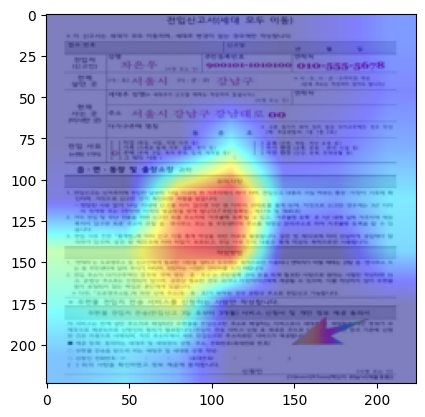

In [17]:
target_layers = [model.features[7][-1]]

cam = GradCAM(model=model,target_layers=target_layers)
grad_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred_class)])[0]

rgb_img = np.array(img.resize((224,224))).astype(np.float32)/255.0
visualization = show_cam_on_image(rgb_img,grad_cam,use_rgb=True)

plt.imshow(visualization)

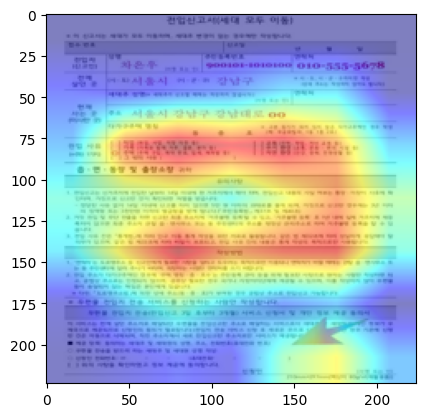

In [31]:
cam = GradCAMPlusPlus(model=model, target_layers=target_layers)

plusplus_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(pred_class)])[0]

rgb_img = np.array(img.resize((224,224))).astype(np.float32)/255.0
visualization = show_cam_on_image(rgb_img,plusplus_cam,use_rgb=True)
plt.imshow(visualization)